In [5]:
import os
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle  # 안정성을 위해 명시적 임포트
from matplotlib.lines import Line2D

In [6]:
# ------------------------------------------------------------------------------
# [환경 설정] 한글 깨짐 방지 및 출력 경로 설정
# ------------------------------------------------------------------------------
# 운영체제에 맞는 한글 폰트를 설정하세요 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 
plt.rc('axes', unicode_minus=False)

out_dir = "./" 
current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# 데이터 로드
df = pd.read_csv('C:/Users/User/Desktop/연구지점 데이터 정리/선행연구 오염원 자료.csv', encoding='euc-kr')
plot_df = df.dropna(subset=['d15N', 'd18O']).copy()

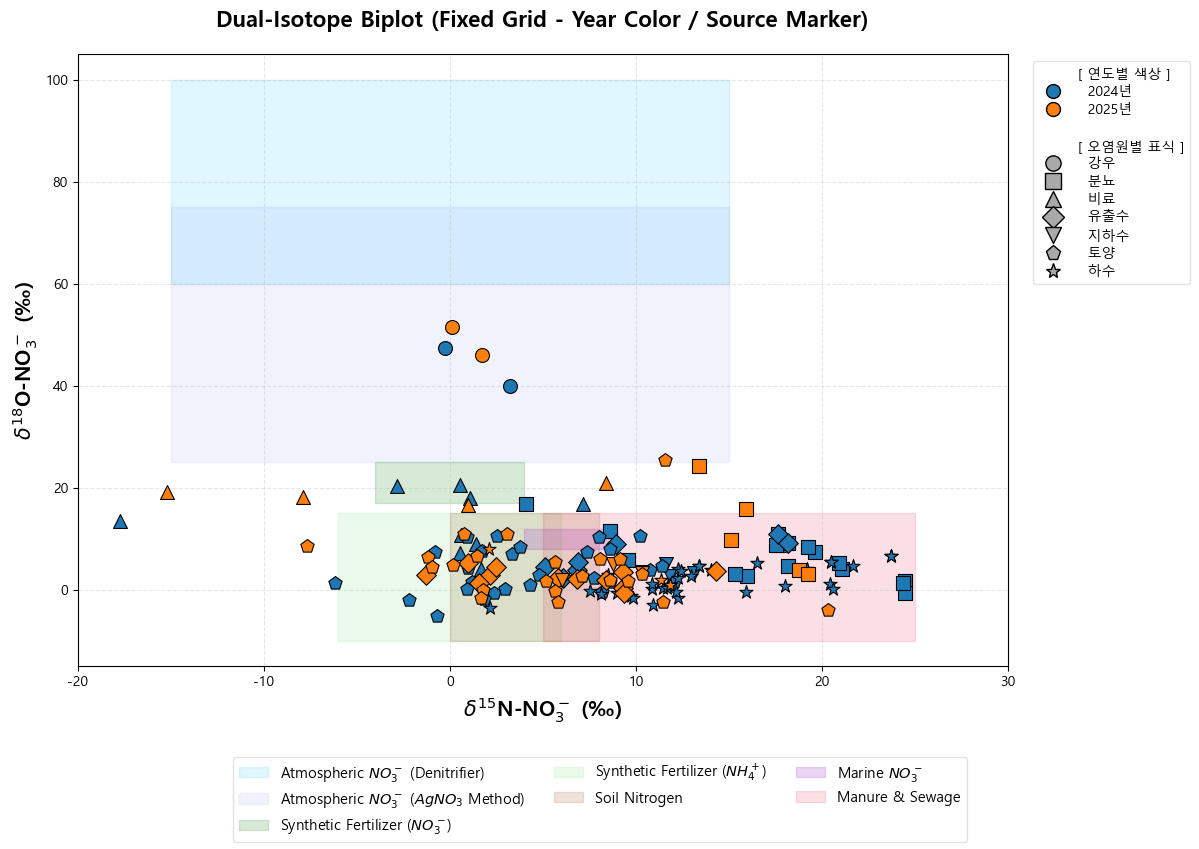

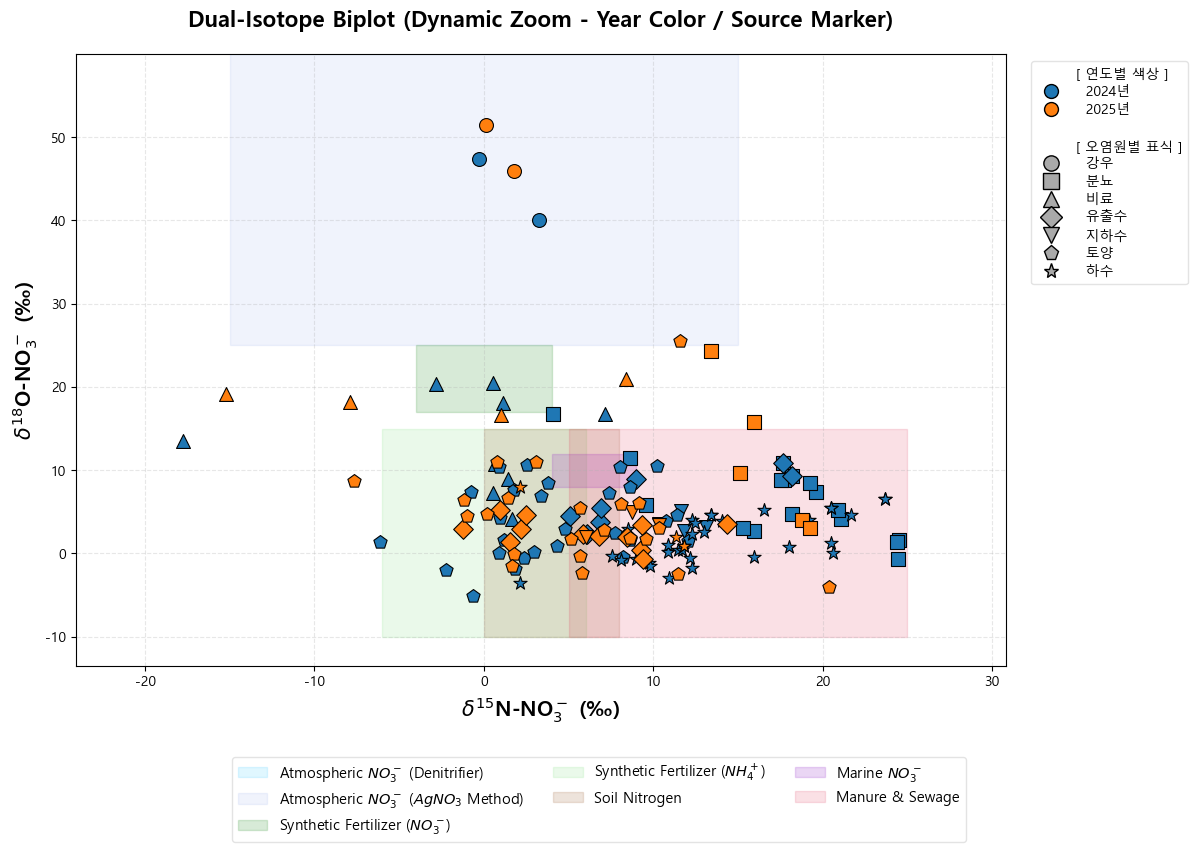

In [7]:
if not plot_df.empty:
    unique_years = sorted(plot_df['year'].unique())
    unique_sources = sorted(plot_df['source'].unique())
    
    # 연도 구분을 위한 컬러 매핑
    distinct_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    color_map = {year: distinct_colors[i % len(distinct_colors)] for i, year in enumerate(unique_years)}
    
    # 오염원별 구분을 위한 고유 마커 매핑 (최대 10개 오염원 지원)
    marker_list = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'X', 'P']
    marker_map = {source: marker_list[i % len(marker_list)] for i, source in enumerate(unique_sources)}

    # --------------------------------------------------------------------------
    # 범례 요소 사전 생성 (우측 데이터 속성 표시용)
    # --------------------------------------------------------------------------
    data_legend_elements = []
    data_legend_elements.append(Line2D([0], [0], color='none', label='[ 연도별 색상 ]'))
    for y in unique_years:
        data_legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[y], markeredgecolor='k', markersize=10, label=f'  {y}'))
        
    data_legend_elements.append(Line2D([0], [0], color='none', label=''))
    data_legend_elements.append(Line2D([0], [0], color='none', label='[ 오염원별 표식 ]'))
    for s in unique_sources:
        data_legend_elements.append(Line2D([0], [0], marker=marker_map[s], color='w', markerfacecolor='darkgray', markeredgecolor='k', markersize=11, label=f'  {s}'))

    # ==============================================================================
    # 1. Dual-Isotope Biplot (버전 1: 고정 축 범위)
    # ==============================================================================
    fig, ax = plt.subplots(figsize=(12, 9))

    # --- 오염원 영역 패치 생성 및 추가 ---
    rect_handles = []
    r1 = Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', label='Atmospheric $NO_3^-$ (Denitrifier)')
    r2 = Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)')
    r3 = Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', label='Synthetic Fertilizer ($NO_3^-$)')
    r4 = Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', label='Synthetic Fertilizer ($NH_4^+$)')
    r5 = Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', label='Soil Nitrogen')
    r6 = Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', label='Marine $NO_3^-$')
    r7 = Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', label='Manure & Sewage')
    
    for r in [r1, r2, r3, r4, r5, r6, r7]:
        ax.add_patch(r)
        rect_handles.append(r)

    # 데이터 scatter 플로팅 (연도별 색상 / 오염원별 마커)
    for (year, source), group in plot_df.groupby(['year', 'source']):
        ax.scatter(group['d15N'], group['d18O'], 
                   color=color_map[year],       
                   marker=marker_map[source],     
                   s=100, edgecolors='k', linewidths=0.8, zorder=4)

    # 축 및 타이틀 디자인 설정
    ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Dual-Isotope Biplot (Fixed Grid - Year Color / Source Marker)", fontsize=16, fontweight='bold', pad=20)
    ax.set_xlim(-20, 30)
    ax.set_ylim(-15, 105)

    # 우측 외부 범례 지정
    ax.legend(handles=data_legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1.0), 
              fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro', labelspacing=0.35)

    # 하단 오염원 범례 설정
    fig.legend(handles=rect_handles, loc='lower center', ncol=3, fontsize=10.5,
               frameon=True, facecolor='white', edgecolor='gainsboro')
    
    plt.subplots_adjust(bottom=0.2) 

    # 이미지 저장 및 화면 출력
    fig.savefig(os.path.join(out_dir, f"05_Dual-Isotope_fixed_year_source_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()

    # ==============================================================================
    # 2. Dual-Isotope Biplot (버전 2: 여백 기반 동적 축 범위 변형)
    # ==============================================================================
    fig, ax = plt.subplots(figsize=(12, 9))

    # 오염원 영역 패치 동일 생성
    rect_handles = []
    r1 = Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', label='Atmospheric $NO_3^-$ (Denitrifier)')
    r2 = Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)')
    r3 = Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', label='Synthetic Fertilizer ($NO_3^-$)')
    r4 = Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', label='Synthetic Fertilizer ($NH_4^+$)')
    r5 = Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', label='Soil Nitrogen')
    r6 = Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', label='Marine $NO_3^-$')
    r7 = Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', label='Manure & Sewage')

    for r in [r1, r2, r3, r4, r5, r6, r7]:
        ax.add_patch(r)
        rect_handles.append(r)

    # 데이터 scatter 플로팅
    for (year, source), group in plot_df.groupby(['year', 'source']):
        ax.scatter(group['d15N'], group['d18O'], 
                   color=color_map[year], 
                   marker=marker_map[source], 
                   s=100, edgecolors='k', linewidths=0.8, zorder=4)

    # 축 및 타이틀 설정
    ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Dual-Isotope Biplot (Dynamic Zoom - Year Color / Source Marker)", fontsize=16, fontweight='bold', pad=20)

    # 동적 축 범위 및 15% 가독성 여백 자동 부여
    x_min, x_max = plot_df['d15N'].min(), plot_df['d15N'].max()
    y_min, y_max = plot_df['d18O'].min(), plot_df['d18O'].max()

    x_padding = (x_max - x_min) * 0.15 if x_max != x_min else 1.0
    y_padding = (y_max - y_min) * 0.15 if y_max != y_min else 1.0

    ax.set_xlim(x_min - x_padding, x_max + x_padding)
    ax.set_ylim(y_min - y_padding, y_max + y_padding)

    # 우측 데이터 범례 설정
    ax.legend(handles=data_legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1.0), 
              fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro', labelspacing=0.35)

    # 하단 오염원 범례 설정
    fig.legend(handles=rect_handles, loc='lower center', ncol=3, fontsize=10.5,
               frameon=True, facecolor='white', edgecolor='gainsboro')

    # 하단 여백 확보
    plt.subplots_adjust(bottom=0.2)

    # 이미지 저장 및 화면 출력
    fig.savefig(os.path.join(out_dir, f"05_Dual-Isotope_dynamic_year_source_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()

else:
    print("[경고] 데이터가 존재하지 않습니다.")

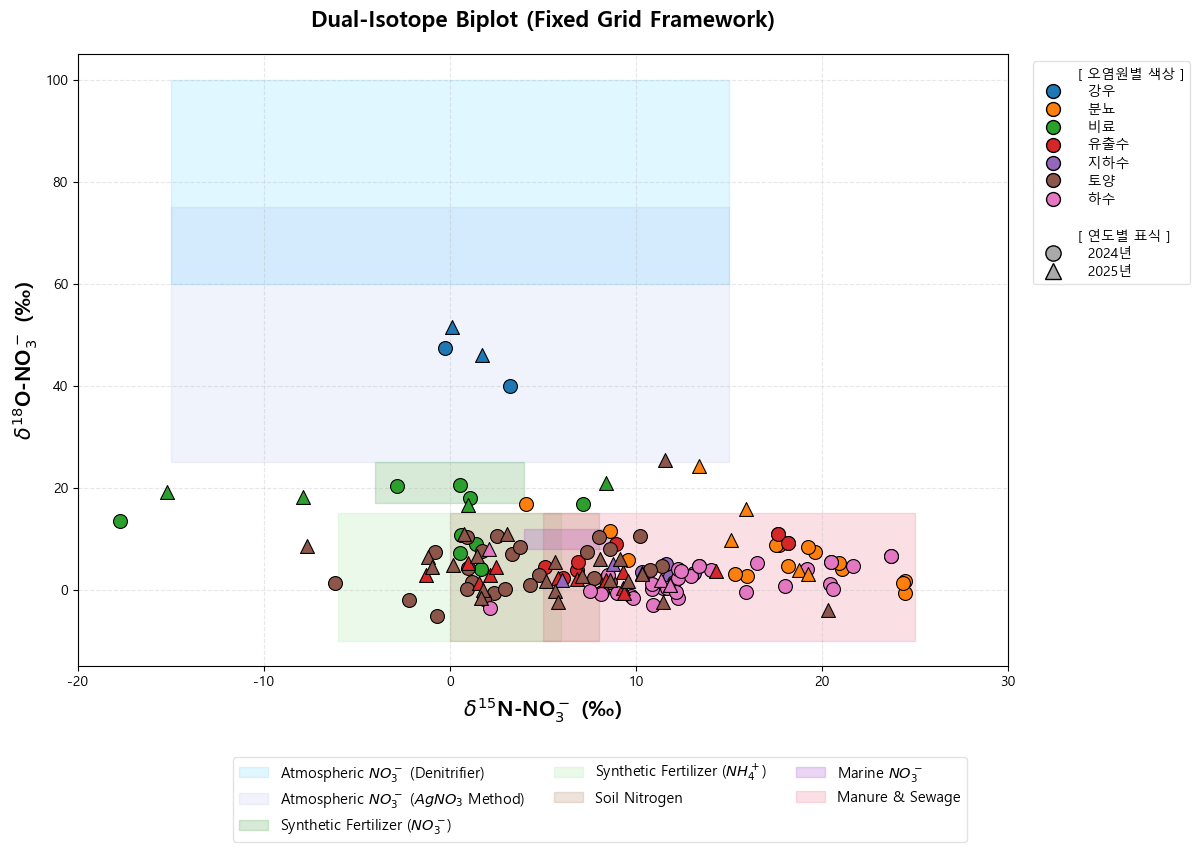

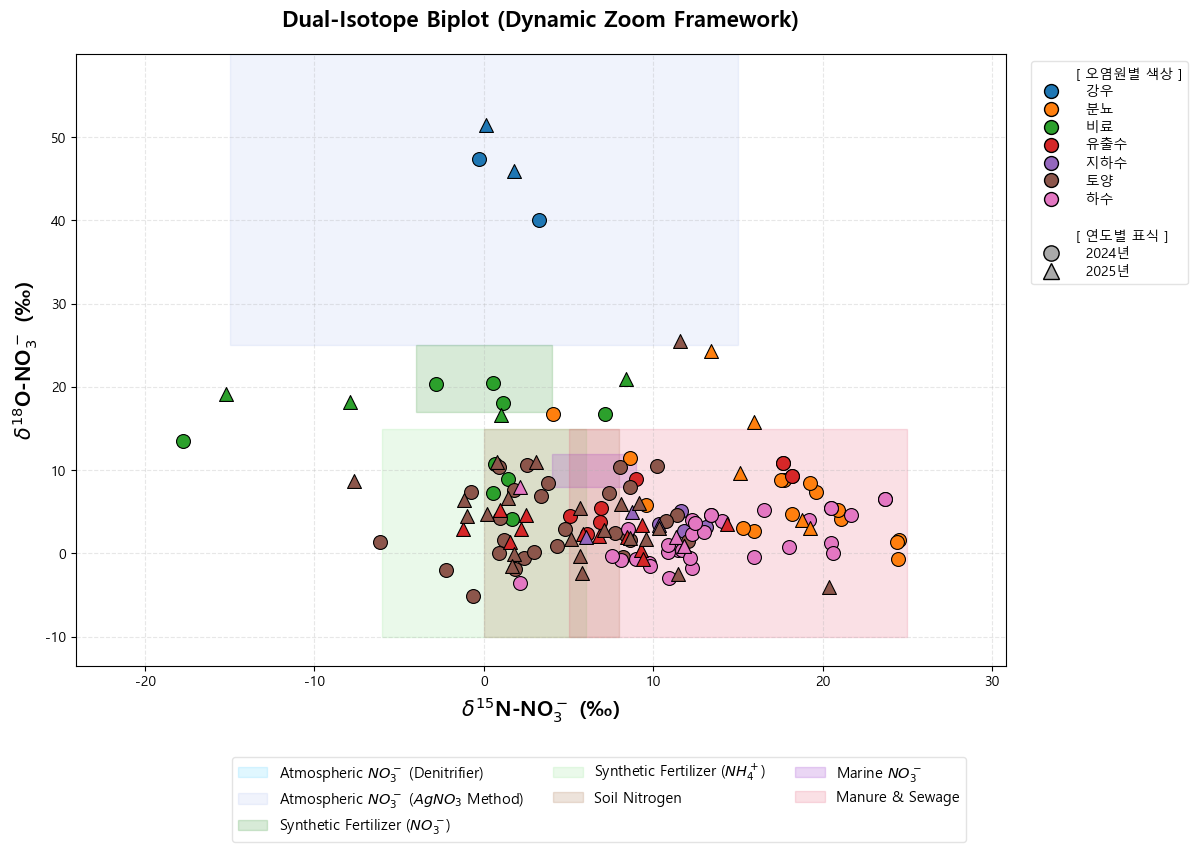

In [8]:
if not plot_df.empty:
    unique_years = sorted(plot_df['year'].unique())
    unique_sources = sorted(plot_df['source'].unique())
    
    # 연도별 표식(Marker) 및 오염원별 색상(Color) 매핑 기준 정의
    distinct_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    color_map = {source: distinct_colors[i % len(distinct_colors)] for i, source in enumerate(unique_sources)}
    
    marker_list = ['o', '^', 's', 'D', 'v', 'p', '*', 'h', 'X', 'P']
    marker_map = {year: marker_list[i % len(marker_list)] for i, year in enumerate(unique_years)}

    # 우측 데이터 속성 범례(오염원 색상 + 연도 표식) 공통 생성
    data_legend_elements = []
    data_legend_elements.append(Line2D([0], [0], color='none', label='[ 오염원별 색상 ]'))
    for s in unique_sources:
        data_legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[s], markeredgecolor='k', markersize=10, label=f'  {s}'))
        
    data_legend_elements.append(Line2D([0], [0], color='none', label=''))
    data_legend_elements.append(Line2D([0], [0], color='none', label='[ 연도별 표식 ]'))
    for y in unique_years:
        data_legend_elements.append(Line2D([0], [0], marker=marker_map[y], color='w', markerfacecolor='darkgray', markeredgecolor='k', markersize=11, label=f'  {y}'))

    # ==============================================================================
    # [버전 1] 전체 오염원 박스 틀이 다 보이는 고정 축 범위 버전 (Fixed Grid)
    # ==============================================================================
    fig, ax = plt.subplots(figsize=(12, 9))

    # 배경 오염원 박스 패치 추가
    rect_handles = []
    r1 = Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', label='Atmospheric $NO_3^-$ (Denitrifier)')
    r2 = Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)')
    r3 = Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', label='Synthetic Fertilizer ($NO_3^-$)')
    r4 = Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', label='Synthetic Fertilizer ($NH_4^+$)')
    r5 = Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', label='Soil Nitrogen')
    r6 = Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', label='Marine $NO_3^-$')
    r7 = Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', label='Manure & Sewage')
    
    for r in [r1, r2, r3, r4, r5, r6, r7]:
        ax.add_patch(r)
        rect_handles.append(r)

    # 산점도 플로팅
    for (year, source), group in plot_df.groupby(['year', 'source']):
        ax.scatter(group['d15N'], group['d18O'], color=color_map[source], marker=marker_map[year], s=100, edgecolors='k', linewidths=0.8, zorder=4)

    # 축 및 타이틀 레이벨링
    ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Dual-Isotope Biplot (Fixed Grid Framework)", fontsize=16, fontweight='bold', pad=20)
    
    # 🌟 [고정 축 핵심 설정] 표준 연구용 전체 프레임워크 그리드 고정
    ax.set_xlim(-20, 30)
    ax.set_ylim(-15, 105)

    # 범례 및 여백 정렬
    ax.legend(handles=data_legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro', labelspacing=0.35)
    fig.legend(handles=rect_handles, loc='lower center', ncol=3, fontsize=10.5, frameon=True, facecolor='white', edgecolor='gainsboro')
    plt.subplots_adjust(bottom=0.2) 
    
    fig.savefig(os.path.join(out_dir, f"06_Biplot_Fixed_Grid_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


    # ==============================================================================
    # [버전 2] 실제 데이터 분포에 집중한 동적 축축약 버전 (Dynamic Zoom)
    # ==============================================================================
    fig, ax = plt.subplots(figsize=(12, 9))

    # 배경 오염원 박스 패치 동일 적용
    rect_handles = []
    r1 = Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', label='Atmospheric $NO_3^-$ (Denitrifier)')
    r2 = Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)')
    r3 = Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', label='Synthetic Fertilizer ($NO_3^-$)')
    r4 = Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', label='Synthetic Fertilizer ($NH_4^+$)')
    r5 = Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', label='Soil Nitrogen')
    r6 = Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', label='Marine $NO_3^-$')
    r7 = Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', label='Manure & Sewage')
    
    for r in [r1, r2, r3, r4, r5, r6, r7]:
        ax.add_patch(r)
        rect_handles.append(r)

    # 산점도 플로팅
    for (year, source), group in plot_df.groupby(['year', 'source']):
        ax.scatter(group['d15N'], group['d18O'], color=color_map[source], marker=marker_map[year], s=100, edgecolors='k', linewidths=0.8, zorder=4)

    ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Dual-Isotope Biplot (Dynamic Zoom Framework)", fontsize=16, fontweight='bold', pad=20)

    # 🌟 [동적 축 핵심 설정] 현재 데이터 분포 경계면을 계산하여 마진 15% 추가 후 축소
    x_min, x_max = plot_df['d15N'].min(), plot_df['d15N'].max()
    y_min, y_max = plot_df['d18O'].min(), plot_df['d18O'].max()
    x_padding = (x_max - x_min) * 0.15 if x_max != x_min else 1.0
    y_padding = (y_max - y_min) * 0.15 if y_max != y_min else 1.0

    ax.set_xlim(x_min - x_padding, x_max + x_padding)
    ax.set_ylim(y_min - y_padding, y_max + y_padding)

    # 범례 및 여백 정렬
    ax.legend(handles=data_legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro', labelspacing=0.35)
    fig.legend(handles=rect_handles, loc='lower center', ncol=3, fontsize=10.5, frameon=True, facecolor='white', edgecolor='gainsboro')
    plt.subplots_adjust(bottom=0.2) 

    fig.savefig(os.path.join(out_dir, f"06_Biplot_Dynamic_Zoom_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

else:
    print("[경고] 플로팅할 유효 데이터가 없습니다.")